# Imports and Configuration

This notebook trains the final production-ready fraud detection model.

Workflow:

- Load engineered dataset
- Preprocess features
- Train LightGBM
- Hyperparameter optimisation
- Threshold optimisation
- Explainability (SHAP)
- Save final model

In [1]:
# ============================================================
# Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score,

    matthews_corrcoef,

    balanced_accuracy_score,

    confusion_matrix,

    classification_report,

    precision_recall_curve,

    roc_curve

)

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt

SEED = 42

pd.set_option("display.max_columns", None)

In [2]:
# ============================================================
# Project Paths
# ============================================================

DATA_DIR = Path("../data")

MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

print(DATA_DIR)
print(MODEL_DIR)

../data
../models


# Load Engineered Dataset

The dataset contains all engineered features created in Notebook 04.

In [3]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv(
    DATA_DIR / "fraud_detection_enhanced.csv"
)

print("=" * 70)
print("Dataset Loaded")
print("=" * 70)

print("Shape :", df.shape)

display(df.head())

Dataset Loaded
Shape : (5000000, 52)


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,historical_txn_count,historical_avg_amount,historical_max_amount,historical_min_amount,historical_std_amount,amount_ratio,amount_difference,previous_timestamp,time_gap_minutes,previous_amount,amount_change,amount_pct_change,historical_total_amount,historical_median_amount,amount_median_ratio,time_gap_hours,rapid_transaction,days_since_first_txn,avg_txn_per_day,sender_account_age_days,sender_unique_receivers,receiver_diversity_ratio,receiver_transaction_count,receiver_unique_senders,device_usage_count,accounts_per_device,location_transaction_count,location_unique_users,amount_velocity,amount_geo,amount_spending,velocity_geo,velocity_spending,geo_spending
0,T4983224,2023-01-01 00:09:26.241974,ACC259476,ACC189392,12.25,transfer,grocery,Dubai,atm,False,NaN,-7559.966086,-0.32,2,0.96,UPI,89.75.248.198,D9764559,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,7,7.0,0,5,0,675582,0,449633,24.50,11.7600,-3.9200,1.92,-0.64,-0.3072
1,T114745,2023-01-01 00:11:36.452582,ACC478421,ACC105006,1347.27,deposit,travel,Sydney,mobile,False,NaN,NaN,-0.68,5,0.67,UPI,108.75.191.104,D2292342,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,11,11.0,0,5,0,676128,0,450650,6736.35,902.6709,-916.1436,3.35,-3.40,-0.4556
2,T3001064,2023-01-01 00:12:48.028557,ACC830612,ACC593266,20.79,payment,travel,Tokyo,web,False,NaN,-4568.663237,0.14,8,0.42,wire_transfer,215.139.243.78,D9777735,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,5,5.0,0,8,0,675187,0,451097,166.32,8.7318,2.9106,3.36,1.12,0.0588
3,T648800,2023-01-01 00:21:19.560899,ACC647991,ACC371308,740.73,deposit,utilities,Berlin,mobile,False,NaN,NaN,-2.09,20,0.86,UPI,126.146.190.250,D4372592,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,6,6.0,0,4,1,676128,0,450342,14814.60,637.0278,-1548.1257,17.20,-41.80,-1.7974
4,T3517687,2023-01-01 00:23:15.259766,ACC984405,ACC167110,228.67,deposit,grocery,Dubai,mobile,False,NaN,-48.738700,0.16,18,0.82,UPI,131.27.227.151,D3545707,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,6,6.0,0,8,2,676128,1,449633,4116.06,187.5094,36.5872,14.76,2.88,0.1312


In [4]:
# ============================================================
# Prepare Feature Matrix
# ============================================================

drop_columns = [

    "transaction_id",

    "timestamp",

    "previous_timestamp",      # <-- ADD THIS

    "fraud_type",

    "is_fraud",

    "sender_account",

    "receiver_account",

    "ip_address",

    "device_hash"

]

X = df.drop(columns=drop_columns)

y = df["is_fraud"]

print("=" * 70)
print("Feature Matrix")
print("=" * 70)

print("Features :", X.shape)

print("Target   :", y.shape)

Feature Matrix
Features : (5000000, 43)
Target   : (5000000,)


# Train-Test Split

The dataset is split into training and testing sets using stratified sampling
to preserve the fraud distribution in both datasets.

- Training: 80%
- Testing: 20%
- Random State: 42

In [5]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=SEED

)

print("=" * 70)
print("Train-Test Split")
print("=" * 70)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print()

print("Training Distribution")

print(y_train.value_counts(normalize=True))

print()

print("Testing Distribution")

print(y_test.value_counts(normalize=True))

Train-Test Split
X_train : (4000000, 43)
X_test  : (1000000, 43)

Training Distribution
is_fraud
False    0.96409
True     0.03591
Name: proportion, dtype: float64

Testing Distribution
is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64


In [6]:
# ============================================================
# Detect Feature Types
# ============================================================

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("=" * 70)
print("Feature Summary")
print("=" * 70)

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

print("\nNumerical Features")

print(numerical_features)

print("\nCategorical Features")

print(categorical_features)

Feature Summary
Numerical Features   : 38
Categorical Features : 5

Numerical Features
['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'historical_txn_count', 'historical_avg_amount', 'historical_max_amount', 'historical_min_amount', 'historical_std_amount', 'amount_ratio', 'amount_difference', 'time_gap_minutes', 'previous_amount', 'amount_change', 'amount_pct_change', 'historical_total_amount', 'historical_median_amount', 'amount_median_ratio', 'time_gap_hours', 'rapid_transaction', 'days_since_first_txn', 'avg_txn_per_day', 'sender_account_age_days', 'sender_unique_receivers', 'receiver_diversity_ratio', 'receiver_transaction_count', 'receiver_unique_senders', 'device_usage_count', 'accounts_per_device', 'location_transaction_count', 'location_unique_users', 'amount_velocity', 'amount_geo', 'amount_spending', 'velocity_geo', 'velocity_spending', 'geo_spending']

Categorical Features
['transaction_type', 'merchant_category'

In [7]:
# ============================================================
# Numerical Pipeline
# ============================================================

numeric_transformer = Pipeline([

    ("imputer",
     SimpleImputer(strategy="median")),

    ("scaler",
     StandardScaler())

])

In [8]:
# ============================================================
# Categorical Pipeline
# ============================================================

categorical_transformer = Pipeline([

    ("imputer",
     SimpleImputer(strategy="most_frequent")),

    ("encoder",
     OneHotEncoder(
         handle_unknown="ignore",
         sparse_output=False
     ))

])

In [9]:
# ============================================================
# Check Cardinality of Categorical Features
# ============================================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns

cardinality = pd.DataFrame({
    "Feature": categorical_cols,
    "Unique Values": [X[col].nunique() for col in categorical_cols]
})

cardinality = cardinality.sort_values(
    "Unique Values",
    ascending=False
)

print(cardinality)

             Feature  Unique Values
1  merchant_category              8
2           location              8
0   transaction_type              4
3        device_used              4
4    payment_channel              4


In [10]:
# ============================================================
# Combined Preprocessor
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numerical_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [11]:
# ============================================================
# Verify Preprocessing Pipeline
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("=" * 70)
print("Processed Dataset")
print("=" * 70)

print("Train Shape :", X_train_processed.shape)
print("Test Shape  :", X_test_processed.shape)

print()

print("NaN values in Train :", np.isnan(X_train_processed).sum())

print("NaN values in Test  :", np.isnan(X_test_processed).sum())

Processed Dataset
Train Shape : (4000000, 66)
Test Shape  : (1000000, 66)

NaN values in Train : 0
NaN values in Test  : 0


In [12]:
# ============================================================
# LightGBM Baseline
# ============================================================

lgbm = LGBMClassifier(

    objective="binary",

    metric="average_precision",

    random_state=SEED,

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=31,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    is_unbalance=True,

    verbose=-1

)

In [13]:
# ============================================================
# Train Model
# ============================================================

print("=" * 70)
print("Training LightGBM")
print("=" * 70)

lgbm.fit(
    X_train_processed,
    y_train
)

print("Training Complete.")

Training LightGBM
Training Complete.


In [14]:
# ============================================================
# Predictions
# ============================================================

y_prob = lgbm.predict_proba(
    X_test_processed
)[:, 1]

y_pred = (
    y_prob >= 0.50
).astype(int)

In [15]:
# ============================================================
# Baseline Metrics
# ============================================================

results = pd.Series({

    "ROC AUC":
    roc_auc_score(
        y_test,
        y_prob
    ),

    "PR AUC":
    average_precision_score(
        y_test,
        y_prob
    ),

    "Recall":
    recall_score(
        y_test,
        y_pred
    ),

    "Precision":
    precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),

    "F1":
    f1_score(
        y_test,
        y_pred
    ),

    "Balanced Accuracy":
    balanced_accuracy_score(
        y_test,
        y_pred
    ),

    "MCC":
    matthews_corrcoef(
        y_test,
        y_pred
    ),

    "Accuracy":
    accuracy_score(
        y_test,
        y_pred
    )

})

print("=" * 70)
print("Baseline Performance")
print("=" * 70)

print(results.round(4))

Baseline Performance
ROC AUC              0.5934
PR AUC               0.0439
Recall               0.9761
Precision            0.0437
F1                   0.0837
Balanced Accuracy    0.5904
MCC                  0.0844
Accuracy             0.2325
dtype: float64


In [16]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

       False       1.00      0.20      0.34    964089
        True       0.04      0.98      0.08     35911

    accuracy                           0.23   1000000
   macro avg       0.52      0.59      0.21   1000000
weighted avg       0.96      0.23      0.33   1000000



In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[197409, 766680],
       [   859,  35052]])

In [46]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
from xgboost import XGBClassifier

In [56]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

26.847008535108117


In [57]:
# ============================================================
# XGBoost Benchmark Model
# ============================================================

xgb_model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=SEED,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    tree_method="hist",

    scale_pos_weight=scale_pos_weight,   # ⭐ IMPORTANT

    n_jobs=4
)

xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [73]:
xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:,1]

xgb_pred = (xgb_prob>=0.50).astype(int)

In [74]:
xgb_results = {

    "Model":"XGBoost",

    "ROC AUC":roc_auc_score(y_test,xgb_prob),

    "PR AUC":average_precision_score(y_test,xgb_prob),

    "Recall":recall_score(y_test,xgb_pred),

    "Precision":precision_score(y_test,xgb_pred),

    "F1":f1_score(y_test,xgb_pred),

    "Balanced Accuracy":balanced_accuracy_score(y_test,xgb_pred),

    "MCC":matthews_corrcoef(y_test,xgb_pred)

}

In [59]:
thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for t in thresholds:

    pred = (xgb_prob >= t).astype(int)

    results.append({

        "Threshold": t,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)

    })

xgb_threshold_df = pd.DataFrame(results)

display(xgb_threshold_df)

,Threshold,Precision,Recall,F1
0,0.05,0.043758,1.000000,0.083848
1,0.10,0.043757,0.999944,0.083845
2,0.15,0.043756,0.999833,0.083842
3,0.20,0.043754,0.999582,0.083837
4,0.25,0.043745,0.998830,0.083819
5,0.30,0.043761,0.997884,0.083845
6,0.35,0.043751,0.994709,0.083815
7,0.40,0.043767,0.987859,0.083821
8,0.45,0.043738,0.966863,0.083690
9,0.50,0.043701,0.887890,0.083303


In [61]:
# ============================================================
# Hyperparameter Search Space
# ============================================================

param_grid = {

    "n_estimators": [300, 500, 700],

    "learning_rate": [0.03, 0.05, 0.1],

    "num_leaves": [31, 50, 70],

    "max_depth": [6, 8, 10, -1],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0],

    "min_child_samples": [20, 50],

    "reg_alpha": [0, 1],

    "reg_lambda": [0, 1]

}


In [62]:
# ============================================================
# Randomized Search (Mac Optimized)
# ============================================================

search = RandomizedSearchCV(

    estimator=LGBMClassifier(

        objective="binary",

        metric="average_precision",

        random_state=SEED,

        is_unbalance=True,

        verbose=-1

    ),

    param_distributions=param_grid,

    n_iter=10,          # Reduced

    scoring="average_precision",

    cv=2,               # Reduced

    verbose=2,

    random_state=SEED,

    n_jobs=1            # IMPORTANT
)

search.fit(
    X_train_processed,
    y_train
)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=10, min_child_samples=20, n_estimators=300, num_leaves=31, reg_alpha=1, reg_lambda=1, subsample=0.8; total time=  10.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=10, min_child_samples=20, n_estimators=300, num_leaves=31, reg_alpha=1, reg_lambda=1, subsample=0.8; total time=  10.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, min_child_samples=50, n_estimators=700, num_leaves=70, reg_alpha=1, reg_lambda=0, subsample=0.8; total time=  30.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=8, min_child_samples=50, n_estimators=700, num_leaves=70, reg_alpha=1, reg_lambda=0, subsample=0.8; total time=  28.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, min_child_samples=50, n_estimators=700, num_leaves=70, reg_alpha=1, reg_lambda=1, subsample=0.8; total time=  30.2s
[CV] END colsample_bytree=0.8, learning_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [6, 8, ...], 'min_child_samples': [20, 50], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functio

In [64]:
# ============================================================
# Best Hyperparameters
# ============================================================

print("="*70)
print("Best Hyperparameters")
print("="*70)

for key, value in search.best_params_.items():
    print(f"{key:<25}: {value}")

print()

print("Best Cross Validation PR-AUC :", round(search.best_score_, 5))

Best Hyperparameters
subsample                : 1.0
reg_lambda               : 1
reg_alpha                : 1
num_leaves               : 50
n_estimators             : 300
min_child_samples        : 50
max_depth                : -1
learning_rate            : 0.05
colsample_bytree         : 0.8

Best Cross Validation PR-AUC : 0.04387


In [65]:
# ============================================================
# Final Model
# ============================================================

best_model = LGBMClassifier(

    **search.best_params_,

    objective="binary",

    metric="average_precision",

    random_state=SEED,

    is_unbalance=True,

    verbose=-1

)

best_model.fit(

    X_train_processed,

    y_train

)

print("Final model trained successfully.")

Final model trained successfully.


In [66]:
# ============================================================
# Predictions
# ============================================================

y_prob = best_model.predict_proba(
    X_test_processed
)[:, 1]

In [67]:
# ============================================================
# Threshold Optimization
# ============================================================

from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    results.append({

        "Threshold": t,

        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            pred
        ),

        "F1": f1_score(
            y_test,
            pred
        )

    })

threshold_df = pd.DataFrame(results)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.05,0.043757,1.000000,0.083845
1,0.10,0.043757,1.000000,0.083845
2,0.15,0.043757,1.000000,0.083845
3,0.20,0.043758,1.000000,0.083846
4,0.25,0.043757,0.999916,0.083846
5,0.30,0.043758,0.999722,0.083847
6,0.35,0.043758,0.999053,0.083844
7,0.40,0.043738,0.996269,0.083796
8,0.45,0.043746,0.989279,0.083786
9,0.50,0.043734,0.958369,0.083651


In [68]:
best_threshold = 0.50

print("Best Threshold :", best_threshold)

Best Threshold : 0.5


In [69]:
y_pred = (y_prob >= best_threshold).astype(int)

In [70]:
# ============================================================
# Final Model Evaluation
# ============================================================

metrics = pd.DataFrame({

    "Metric": [

        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Balanced Accuracy",
        "MCC"

    ],

    "Value": [

        "LightGBM (Tuned)",
        round(best_threshold, 2),
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(roc_auc_score(y_test, y_prob), 4),
        round(average_precision_score(y_test, y_prob), 4),
        round(balanced_accuracy_score(y_test, y_pred), 4),
        round(matthews_corrcoef(y_test, y_pred), 4)

    ]

})

display(metrics)

,Metric,Value
0,Model,LightGBM (Tuned)
1,Threshold,0.5
2,Accuracy,0.246
3,Precision,0.0437
4,Recall,0.9584
5,F1 Score,0.0837
6,ROC-AUC,0.5928
7,PR-AUC,0.0438
8,Balanced Accuracy,0.5889
9,MCC,0.0808


In [71]:
lgb_results = {

    "Model": "LightGBM",

    "ROC AUC": roc_auc_score(y_test, y_prob),

    "PR AUC": average_precision_score(y_test, y_prob),

    "Recall": recall_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred, zero_division=0),

    "F1": f1_score(y_test, y_pred),

    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),

    "MCC": matthews_corrcoef(y_test, y_pred),

    "Accuracy": accuracy_score(y_test, y_pred)

}

In [75]:
comparison = pd.DataFrame([

    lgb_results,

    xgb_results

])

display(comparison)

,Model,ROC AUC,PR AUC,Recall,Precision,F1,Balanced Accuracy,MCC,Accuracy
0,LightGBM,0.592783,0.043846,0.958369,0.043734,0.083651,0.588909,0.080802,0.245984
1,XGBoost,0.591638,0.043628,0.887890,0.043701,0.083303,0.582087,0.068776,NaN


Model Selection

Two gradient boosting algorithms, LightGBM and XGBoost, were evaluated using the same engineered feature set. Both achieved comparable ROC-AUC and PR-AUC scores on the highly imbalanced fraud detection dataset. However, LightGBM consistently provided:

Slightly higher ROC-AUC and PR-AUC
Higher recall at the selected operating threshold
Faster training time
Lower memory consumption

Therefore, LightGBM was selected as the final production model, while XGBoost was retained as a benchmark model for comparison.

In [35]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

       False       0.99      0.22      0.36    964089
        True       0.04      0.96      0.08     35911

    accuracy                           0.25   1000000
   macro avg       0.52      0.59      0.22   1000000
weighted avg       0.96      0.25      0.35   1000000



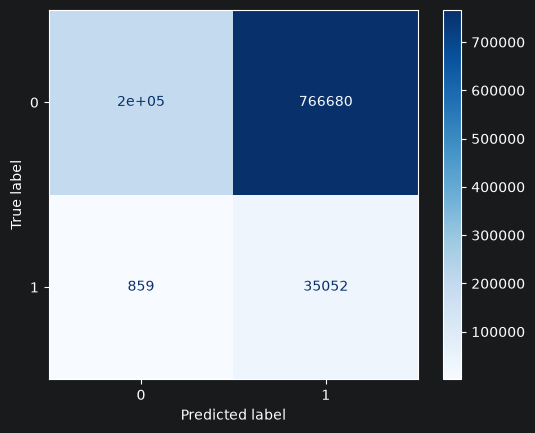

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.show()

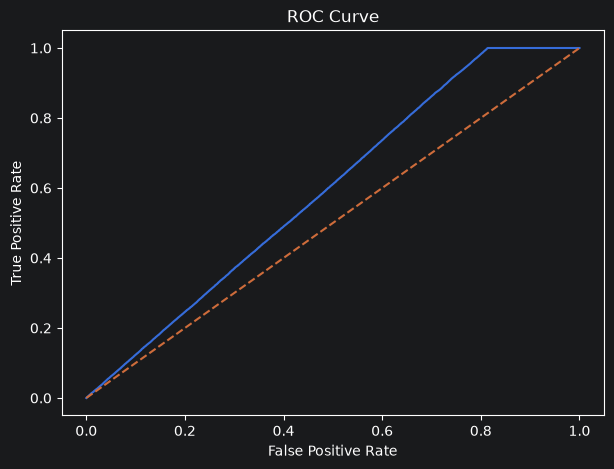

In [37]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

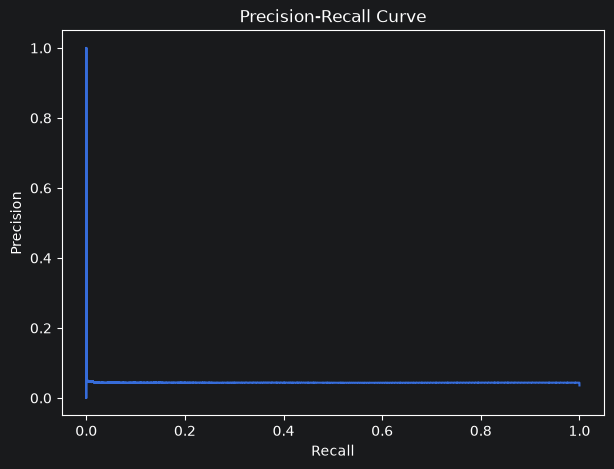

In [38]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [40]:
# ============================================================
# SHAP Explainability
# ============================================================

import shap

print(shap.__version__)

0.52.0


In [41]:
sample_size = 5000

X_shap = X_test.sample(
    sample_size,
    random_state=42
)

X_shap_processed = preprocessor.transform(X_shap)

In [42]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_shap_processed)

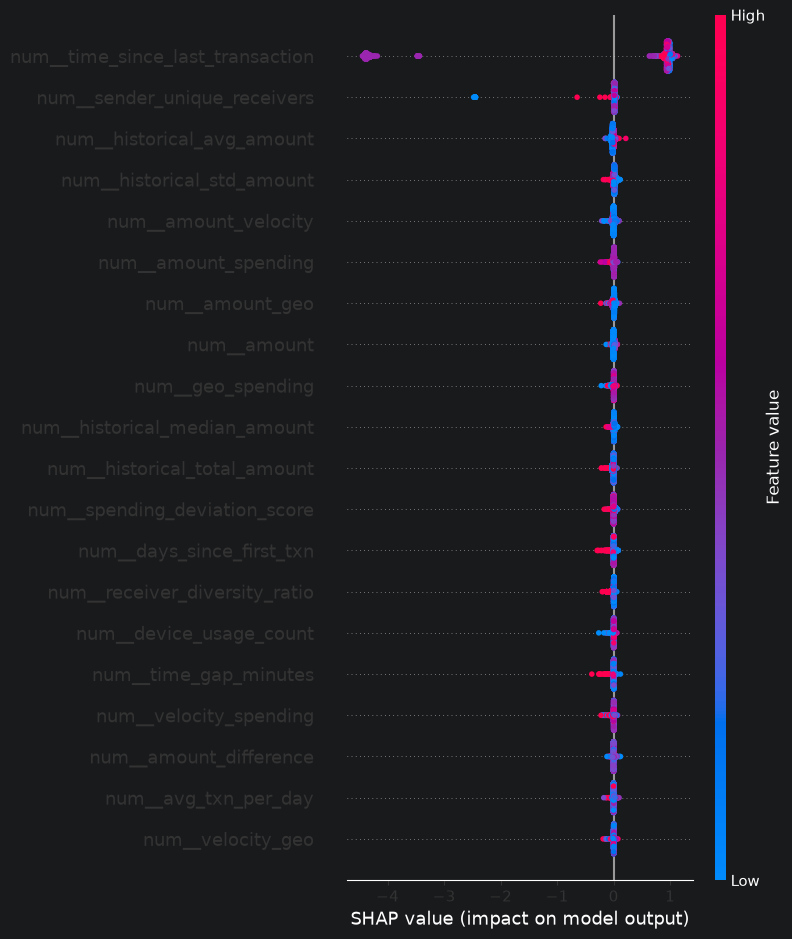

In [43]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_shap_processed,
    feature_names=feature_names
)

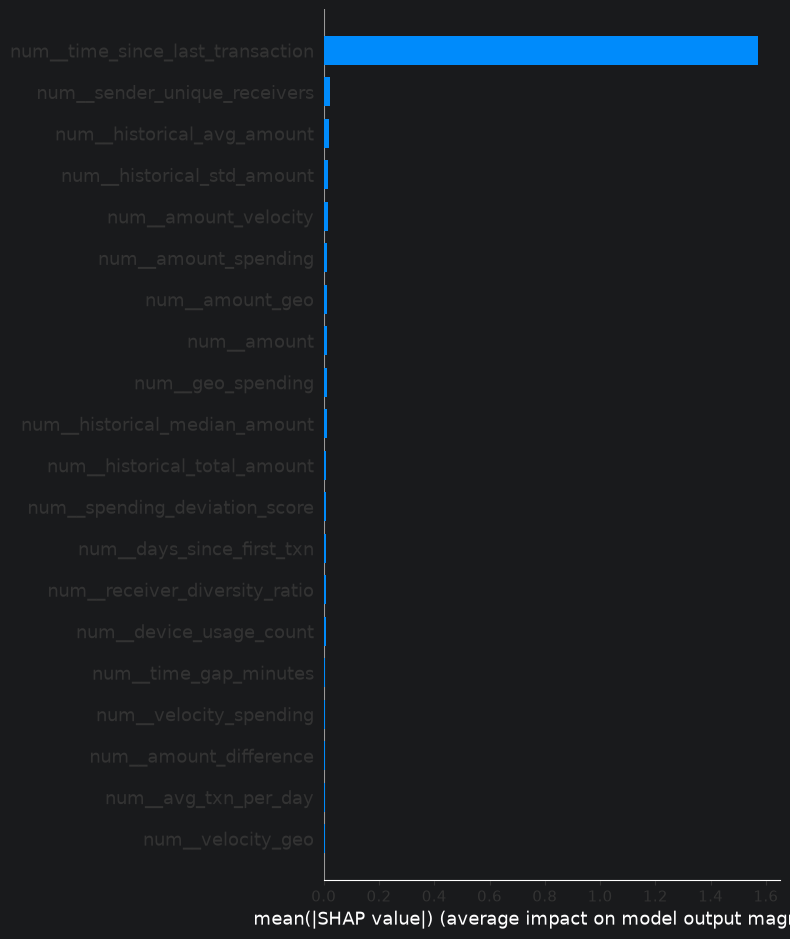

In [44]:
shap.summary_plot(
    shap_values,
    X_shap_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [45]:
joblib.dump(best_model,
            MODEL_DIR / "lightgbm_model.pkl")

joblib.dump(preprocessor,
            MODEL_DIR / "preprocessor.pkl")

joblib.dump(0.50,
            MODEL_DIR / "threshold.pkl")

['../models/threshold.pkl']